# Part C – Legal Amount Recognition (Improved)
**ICS472 – Natural Language Processing**  
**Team:** Mohammed Al Sheqaih · Abdulrhman Ammar

This notebook extends the baseline CRNN from `03_Part_C_Legal.ipynb` with four key improvements from the paper:

| # | Improvement | Effect |
|---|-------------|--------|
| A | **Enhanced Word-Level Tokenization** — spelling normalization collapses variant Arabic spellings into a single canonical form | Smaller vocabulary → more training samples per class |
| B | **Character-Level Tokenization** — 24 Arabic letters + space replace ~130 sub-word tokens | Dramatically fewer classes, more balanced dataset |
| C | **Dictionary Matching & Linear Search** — post-processing layer fixes broken or merged words using Minimum Edit Distance | Catches CTC transcription errors at inference time |
| D | **Mutual Enhancement** — use the Courtesy Amount prediction as a tie-breaker when MED returns multiple candidates | Boosts legal accuracy from ~66 % → ~83 % |

> **Prerequisites:** `01_Part_A_Detection.ipynb` (legal crops) and `02_Part_B_Courtesy.ipynb` (courtesy predictions JSON).

## 1. Imports & Setup

In [1]:
import sys, os, json, random
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

from utils import (
    TRAIN_LA, TEST_LA, ARTIFACTS,
    parse_legal_amounts,
    build_vocab, legal_summary, edit_distance,
    legal_text_to_digits,
)

# ── Device ──────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'
print(f'Device: {DEVICE}')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
plt.rcParams['figure.dpi'] = 120

CROPS_DIR = ARTIFACTS / 'crops'
MODEL_DIR = ARTIFACTS / 'legal_model_improved'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# ── Shared Hyper-parameters ──────────────────────────────────────────────────
IMG_H    = 32
MIN_W    = 160
HIDDEN   = 256
N_LSTM   = 2
EPOCHS   = 150
BATCH    = 16
LR       = 5e-4
PATIENCE = 25
BLANK    = 0

Device: cuda


## 2. Load Raw Labels

In [2]:
train_labels_raw = parse_legal_amounts(TRAIN_LA)
test_labels_raw  = parse_legal_amounts(TEST_LA)

print(f'Train: {len(train_labels_raw)} samples')
print(f'Test : {len(test_labels_raw)} samples')

# Peek at a few raw labels
for fname, toks in list(train_labels_raw.items())[:3]:
    print(f'  {fname}: {toks}')

Train: 1799 samples
Test : 600 samples
  Lac00000.tif: ['ثمانيه', 'و', 'اربع', 'و', 'ن', 'أ', 'لف', 'و', 'ستمائ', 'ة', 'و', 'سته', 'و', 'عشر', 'و', 'ن', 'ر', 'يا', 'ل']
  Lac00001.tif: ['أ', 'لف', 'و', 'ثلاثمائ', 'ة', 'و', 'خمس', 'و', 'ن', 'ر', 'يا', 'ل', 'فقط', 'لا', 'غير']
  Lac00002.tif: ['فقط', 'أ', 'لف', 'و', 'خمسمائه', 'ر', 'يا', 'ل', 'لا', 'غير']


## 3. Tokenization Strategies

### 3A — Enhanced Word-Level Tokenization

The original vocabulary contains **orthographic duplicates** — the same Arabic word written with
different characters (e.g. `مائة` / `مائه` / `مئة` all mean "100").
We apply a **spelling normalization map** before building the vocabulary so that every such group
collapses into a single canonical token. This:
- reduces the vocabulary from ~130 sub-word tokens to a smaller set,
- increases the number of training examples that train each class, and
- makes the post-processing dictionary smaller and more precise.

In [3]:
# ── Spelling Normalization Map ───────────────────────────────────────────────
# Maps variant Arabic spellings to a single canonical form.
# Covers two main orthographic variation axes:
#   (1) alef variants  (أ / إ / آ  →  ا)
#   (2) taa-marbuta   (ه  ←→  ة)
# plus a handful of word-specific colloquial vs. formal alternatives.

SPELLING_MAP = {
    # ── Hundreds ──────────────────────────────────────────────────────────
    'مائه'      : 'مائة',
    'مئة'       : 'مائة',
    'مئه'       : 'مائة',
    'مئتان'     : 'مائتان',
    'مئتين'     : 'مائتين',
    'مائتين'    : 'مائتان',
    'ثلاثمائه'  : 'ثلاثمائة',
    'ثلثمائة'   : 'ثلاثمائة',
    'ثلثمائه'   : 'ثلاثمائة',
    'اربعمائة'  : 'أربعمائة',
    'أربعمائه'  : 'أربعمائة',
    'اربعمائه'  : 'أربعمائة',
    'خمسمائه'   : 'خمسمائة',
    'خمسمئة'    : 'خمسمائة',
    'ستمائه'    : 'ستمائة',
    'ستمئة'     : 'ستمائة',
    'سبعمائه'   : 'سبعمائة',
    'ثمانمائه'  : 'ثمانمائة',
    'ثمانيمائة' : 'ثمانمائة',
    'ثمانيمائه' : 'ثمانمائة',
    'تسعمائه'   : 'تسعمائة',
    # ── Thousands ─────────────────────────────────────────────────────────
    'الف'       : 'ألف',
    'الفا'      : 'ألفا',
    'الفين'     : 'ألفين',
    'آلاف'      : 'ألاف',
    'آلافا'     : 'ألافا',
    # ── Units / tens – alef normalization ─────────────────────────────────
    'اربع'      : 'أربع',
    'اربعة'     : 'أربعة',
    'اربعون'    : 'أربعون',
    'اربعين'    : 'أربعين',
    'احدى'      : 'إحدى',
    'احد'       : 'أحد',
    # ── taa-marbuta harmonization ─────────────────────────────────────────
    'ثمانيه'    : 'ثمانية',
    'سته'       : 'ستة',
    'ثلاثه'     : 'ثلاثة',
    'خمسه'      : 'خمسة',
    'سبعه'      : 'سبعة',
    'تسعه'      : 'تسعة',
    'عشره'      : 'عشرة',
}


def normalize_token(tok):
    """Apply spelling normalization to a single sub-word token."""
    return SPELLING_MAP.get(tok, tok)


def normalize_sequence(token_list):
    """Normalize every token in a label sequence."""
    return [normalize_token(t) for t in token_list]


# Apply normalization
train_labels_wl = {k: normalize_sequence(v) for k, v in train_labels_raw.items()}
test_labels_wl  = {k: normalize_sequence(v) for k, v in test_labels_raw.items()}

# Build normalized vocabulary
all_wl_seqs = list(train_labels_wl.values()) + list(test_labels_wl.values())
wl_vocab, wl_t2i, wl_i2t = build_vocab(all_wl_seqs)

# Compare with raw vocab
raw_all = list(train_labels_raw.values()) + list(test_labels_raw.values())
raw_vocab, _, _ = build_vocab(raw_all)

print(f'Raw vocab size          : {len(raw_vocab)} tokens')
print(f'Normalized vocab size   : {len(wl_vocab)} tokens')
print(f'Tokens eliminated       : {len(raw_vocab) - len(wl_vocab)}')

Raw vocab size          : 288 tokens
Normalized vocab size   : 270 tokens
Tokens eliminated       : 18


### 3B — Character-Level Tokenization

Instead of sub-word tokens (~130 classes), we treat **each Arabic character** as an atomic label.
Number words in Arabic use only a subset of the alphabet — the paper reports **24 distinct characters
plus space**, giving ≈ 25 classes (plus the CTC blank).
This has two advantages:
- Every class has far more training samples → stabler CTC gradient.
- The character-level representation can be post-processed word-by-word using a dictionary.

In [4]:
def tokens_to_chars(token_list):
    """
    Convert a sub-word token list to a character sequence.
    Consecutive tokens are joined without a separator; a single space is
    inserted between tokens that represent distinct words so the decoder
    can recover word boundaries.

    Heuristic: a token is a 'word-starter' when the previous token is a
    complete word (length ≥ 2 and not a single Arabic letter suffix).
    For simplicity, we join all tokens with no space (the space character
    is never present in the raw annotations anyway).
    """
    joined = ''.join(token_list)   # concatenate all fragments
    return list(joined)            # split into individual characters


train_labels_cl = {k: tokens_to_chars(v) for k, v in train_labels_raw.items()}
test_labels_cl  = {k: tokens_to_chars(v) for k, v in test_labels_raw.items()}

# Build character vocabulary
all_cl_seqs = list(train_labels_cl.values()) + list(test_labels_cl.values())
cl_vocab, cl_t2i, cl_i2t = build_vocab(all_cl_seqs)

print(f'Character vocab size    : {len(cl_vocab)} tokens (incl. <blank>)')
print(f'Unique chars in data    : {len(cl_vocab) - 1}')
print(f'Characters: {sorted(cl_vocab[1:])}')

Character vocab size    : 53 tokens (incl. <blank>)
Unique chars in data    : 52
Characters: ['#', '/', '0', '1', '4', '6', '،', 'ء', 'آ', 'أ', 'إ', 'ئ', 'ا', 'ب', 'ة', 'ت', 'ث', 'ج', 'ح', 'خ', 'د', 'ر', 'س', 'ش', 'ص', 'ض', 'ط', 'ظ', 'ع', 'غ', 'ف', 'ق', 'ك', 'ل', 'م', 'ن', 'ه', 'و', 'ى', 'ي', 'ً', '٠', '١', '٢', '٣', '٤', '٥', '٦', '٧', '٨', '٩', '⁄']


### 3C — Vocabulary Summary

In [5]:
modes = [
    ('Baseline sub-word',          raw_vocab),
    ('Enhanced word-level (norm)', wl_vocab),
    ('Character-level',            cl_vocab),
]

header = '{:<30} {:>12} {:>26}'.format('Mode', 'Vocab size', 'Samples / class (approx)')
print(header)
print('-' * 70)
n_train = len(train_labels_raw)
avg_len = np.mean([len(v) for v in train_labels_raw.values()])
for name, vocab in modes:
    n_cls = len(vocab) - 1  # exclude blank
    spc   = n_train * avg_len / max(n_cls, 1)
    print('{:<30} {:>12} {:>26.1f}'.format(name, len(vocab), spc))

Mode                             Vocab size   Samples / class (approx)
----------------------------------------------------------------------
Baseline sub-word                       288                       90.5
Enhanced word-level (norm)              270                       96.5
Character-level                          53                      499.4


## 4. Dataset & DataLoader

A single `LegalDataset` class accepts a `label_dict` keyed by filename and a `tokenize_fn`
that maps the raw sub-word token list to whatever label representation is desired.

In [6]:
class LegalDataset(Dataset):
    def __init__(self, crops_dir, labels, t2i, img_h=32, min_w=160):
        """
        labels : dict  filename → list of label tokens (already tokenized)
        t2i    : dict  token → int index
        """
        self.t2i   = t2i
        self.img_h = img_h
        self.min_w = min_w
        self.samples = []

        for img_path in sorted(crops_dir.glob('*.tif')):
            key = img_path.name
            if key in labels and len(labels[key]) > 0:
                self.samples.append((img_path, labels[key]))

        print(f'Dataset: {len(self.samples)} samples from {crops_dir.parent.name}/{crops_dir.name}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, token_seq = self.samples[idx]
        img = Image.open(img_path).convert('L')

        w, h  = img.size
        new_w = max(self.min_w, int(w * self.img_h / h))
        img   = img.resize((new_w, self.img_h), Image.BILINEAR)
        # Flip horizontally so the CRNN time axis (left→right) matches
        # Arabic RTL reading order (right→left).
        img   = img.transpose(Image.FLIP_LEFT_RIGHT)
        img_t = T.ToTensor()(img)

        label = torch.tensor(
            [self.t2i[t] for t in token_seq if t in self.t2i],
            dtype=torch.long
        )
        return img_t, label


def make_collate(img_h):
    def collate_fn(batch):
        imgs, labels = zip(*batch)
        max_w  = max(img.shape[2] for img in imgs)
        padded = torch.ones(len(imgs), 1, img_h, max_w)
        for i, img in enumerate(imgs):
            padded[i, :, :, :img.shape[2]] = img
        label_lengths = torch.tensor([len(l) for l in labels], dtype=torch.long)
        labels_cat    = torch.cat(labels)
        input_lengths = torch.tensor([max_w // 4 for _ in imgs], dtype=torch.long)
        return padded, labels_cat, input_lengths, label_lengths
    return collate_fn


collate_fn = make_collate(IMG_H)


def make_loaders(crops_dir, train_labels, test_labels, t2i):
    train_ds = LegalDataset(crops_dir / 'train' / 'legal', train_labels, t2i, IMG_H, MIN_W)
    test_ds  = LegalDataset(crops_dir / 'test'  / 'legal', test_labels,  t2i, IMG_H, MIN_W)

    val_size   = int(0.1 * len(train_ds))
    train_size = len(train_ds) - val_size
    train_sub, val_sub = torch.utils.data.random_split(
        train_ds, [train_size, val_size],
        generator=torch.Generator().manual_seed(SEED)
    )

    train_loader = DataLoader(train_sub, batch_size=BATCH, shuffle=True,
                              collate_fn=collate_fn, num_workers=0, pin_memory=True)
    val_loader   = DataLoader(val_sub,   batch_size=BATCH, shuffle=False,
                              collate_fn=collate_fn, num_workers=0, pin_memory=True)
    test_loader  = DataLoader(test_ds,   batch_size=BATCH, shuffle=False,
                              collate_fn=collate_fn, num_workers=0, pin_memory=True)

    print(f'  → train {train_size} | val {val_size} | test {len(test_ds)}')
    return train_loader, val_loader, test_loader, train_ds, test_ds

In [7]:
print('── Enhanced word-level loaders ──')
wl_train_loader, wl_val_loader, wl_test_loader, wl_train_ds, wl_test_ds = \
    make_loaders(CROPS_DIR, train_labels_wl, test_labels_wl, wl_t2i)

print('── Character-level loaders ──')
cl_train_loader, cl_val_loader, cl_test_loader, cl_train_ds, cl_test_ds = \
    make_loaders(CROPS_DIR, train_labels_cl, test_labels_cl, cl_t2i)

── Enhanced word-level loaders ──
Dataset: 1798 samples from train/legal
Dataset: 600 samples from test/legal
  → train 1619 | val 179 | test 600
── Character-level loaders ──
Dataset: 1798 samples from train/legal
Dataset: 600 samples from test/legal
  → train 1619 | val 179 | test 600


## 5. CRNN Model

Same architecture as the baseline (7-block CNN backbone → 2-layer BiLSTM → CTC head),
but the output layer size is parameterised so the same class can serve both vocab sizes.

In [8]:
def conv_bn_relu(in_ch, out_ch):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 3, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
    )


class CRNN(nn.Module):
    def __init__(self, n_classes, hidden=256, n_lstm=2):
        super().__init__()
        self.cnn = nn.Sequential(
            conv_bn_relu(1,   64),  nn.MaxPool2d(2, 2),
            conv_bn_relu(64,  128), nn.MaxPool2d(2, 2),
            conv_bn_relu(128, 256), conv_bn_relu(256, 256), nn.MaxPool2d((2, 1)),
            conv_bn_relu(256, 512), conv_bn_relu(512, 512), nn.MaxPool2d((2, 1)),
            conv_bn_relu(512, 512), nn.MaxPool2d((2, 1)),
        )
        self.lstm = nn.LSTM(
            input_size=512, hidden_size=hidden,
            num_layers=n_lstm, bidirectional=True,
            batch_first=False, dropout=0.2 if n_lstm > 1 else 0
        )
        self.fc = nn.Linear(hidden * 2, n_classes)

    def forward(self, x):
        x = self.cnn(x)           # (B, 512, 1, W//4)
        x = x.squeeze(2)          # (B, 512, T)
        x = x.permute(2, 0, 1)   # (T, B, 512)
        x, _ = self.lstm(x)       # (T, B, hidden*2)
        x = self.fc(x)            # (T, B, n_classes)
        return torch.log_softmax(x, dim=-1)


wl_model = CRNN(len(wl_vocab), hidden=HIDDEN, n_lstm=N_LSTM).to(DEVICE)
cl_model = CRNN(len(cl_vocab), hidden=HIDDEN, n_lstm=N_LSTM).to(DEVICE)

print(f'Word-level model parameters : {sum(p.numel() for p in wl_model.parameters() if p.requires_grad):,}')
print(f'Char-level model parameters : {sum(p.numel() for p in cl_model.parameters() if p.requires_grad):,}')

Word-level model parameters : 10,156,430
Char-level model parameters : 10,045,109


## 6. Training

A shared `run_epoch` / `train_model` function trains either model; we run both and compare.

In [9]:
def greedy_decode(log_probs, i2t, blank=BLANK):
    """CTC greedy decoder — collapses repeated tokens and removes blanks."""
    indices = log_probs.argmax(dim=-1).cpu().tolist()
    tokens, prev = [], None
    for idx in indices:
        if idx != prev:
            tokens.append(idx)
        prev = idx
    return [i2t[i] for i in tokens if i != blank]


def token_accuracy(refs, hyps):
    """1 - CER, expressed as a percentage."""
    total_N, total_ed = 0, 0
    for r, h in zip(refs, hyps):
        total_ed += edit_distance(r, h)
        total_N  += len(r)
    return max(0.0, (1 - total_ed / max(total_N, 1))) * 100


def run_epoch(loader, model, criterion, i2t, optimiser=None):
    training = optimiser is not None
    model.train() if training else model.eval()
    total_loss = 0
    refs, hyps = [], []

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, labels, in_lens, lbl_lens in loader:
            imgs      = imgs.to(DEVICE)
            log_probs = model(imgs)
            T_actual  = log_probs.size(0)
            in_lens   = torch.clamp(in_lens, max=T_actual)

            loss = criterion(
                log_probs, labels.to(DEVICE),
                in_lens.to(DEVICE), lbl_lens.to(DEVICE)
            )
            if training:
                optimiser.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                optimiser.step()

            total_loss += loss.item()

            offset = 0
            for i, llen in enumerate(lbl_lens.tolist()):
                ref = [i2t[idx] for idx in labels[offset:offset + llen].tolist()]
                hyp = greedy_decode(log_probs[:, i, :], i2t)
                refs.append(ref); hyps.append(hyp)
                offset += llen

    return total_loss / len(loader), token_accuracy(refs, hyps)


def train_model(model, i2t, train_loader, val_loader, save_path, tag):
    """Full training loop with early stopping; returns history dict."""
    criterion = nn.CTCLoss(blank=BLANK, reduction='mean', zero_infinity=True)
    optimiser = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimiser, mode='max', factor=0.5, patience=8, min_lr=1e-5
    )

    best_val_acc = -1
    patience_ctr = 0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = run_epoch(train_loader, model, criterion, i2t, optimiser)
        vl_loss, vl_acc = run_epoch(val_loader,   model, criterion, i2t)
        scheduler.step(vl_acc)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            patience_ctr = 0
            torch.save(model.state_dict(), save_path)
            flag = ' ✓'
        else:
            patience_ctr += 1
            flag = ''

        print(f'[{tag}] Ep {epoch:>3}/{EPOCHS} | '
              f'tr {tr_loss:.4f}/{tr_acc:.1f}% | '
              f'val {vl_loss:.4f}/{vl_acc:.1f}%{flag}', flush=True)

        if patience_ctr >= PATIENCE:
            print(f'Early stopping at epoch {epoch}.', flush=True)
            break

    print(f'[{tag}] Best val accuracy: {best_val_acc:.2f}%', flush=True)
    return history, best_val_acc

In [10]:
# ── Train enhanced word-level model ─────────────────────────────────────────
wl_history, wl_best_val = train_model(
    wl_model, wl_i2t,
    wl_train_loader, wl_val_loader,
    MODEL_DIR / 'best_wl.pt',
    tag='WL'  
)

[WL] Ep   1/150 | tr 5.3176/0.0% | val 3.1727/4.7% ✓
[WL] Ep   2/150 | tr 2.7943/11.9% | val 2.5790/22.4% ✓
[WL] Ep   3/150 | tr 2.4372/26.2% | val 2.4773/29.5% ✓
[WL] Ep   4/150 | tr 2.2894/31.1% | val 2.6123/33.8% ✓
[WL] Ep   5/150 | tr 2.2344/32.8% | val 2.2342/34.3% ✓
[WL] Ep   6/150 | tr 2.1500/33.7% | val 2.3353/34.0%
[WL] Ep   7/150 | tr 2.1026/33.5% | val 2.2098/34.1%
[WL] Ep   8/150 | tr 2.0309/35.2% | val 2.1488/44.2% ✓
[WL] Ep   9/150 | tr 1.9564/42.6% | val 2.0869/46.6% ✓
[WL] Ep  10/150 | tr 1.8314/44.7% | val 1.9597/43.1%
[WL] Ep  11/150 | tr 1.7489/45.7% | val 2.0942/44.1%
[WL] Ep  12/150 | tr 1.6241/47.9% | val 1.6879/51.7% ✓
[WL] Ep  13/150 | tr 1.5025/53.4% | val 1.8166/48.9%
[WL] Ep  14/150 | tr 1.3923/57.5% | val 1.6550/50.6%
[WL] Ep  15/150 | tr 1.3015/60.1% | val 1.5541/56.1% ✓
[WL] Ep  16/150 | tr 1.1983/63.1% | val 1.4204/60.2% ✓
[WL] Ep  17/150 | tr 1.1559/64.4% | val 1.3966/61.5% ✓
[WL] Ep  18/150 | tr 1.0658/66.9% | val 1.3240/62.3% ✓
[WL] Ep  19/150 | tr 1.0

In [11]:
# ── Train character-level model ──────────────────────────────────────────────
cl_history, cl_best_val = train_model(
    cl_model, cl_i2t,
    cl_train_loader, cl_val_loader,
    MODEL_DIR / 'best_cl.pt',
    tag='CL'
)

[CL] Ep   1/150 | tr 3.4435/0.0% | val 2.9172/0.0% ✓
[CL] Ep   2/150 | tr 2.7626/3.4% | val 2.7105/3.7% ✓
[CL] Ep   3/150 | tr 2.4954/10.3% | val 2.5223/18.9% ✓
[CL] Ep   4/150 | tr 2.3146/19.5% | val 2.2701/22.7% ✓
[CL] Ep   5/150 | tr 2.1375/23.2% | val 2.5168/22.2%
[CL] Ep   6/150 | tr 1.9671/29.1% | val 1.9965/32.2% ✓
[CL] Ep   7/150 | tr 1.8217/35.7% | val 1.8538/43.2% ✓
[CL] Ep   8/150 | tr 1.6367/42.8% | val 1.6734/45.5% ✓
[CL] Ep   9/150 | tr 1.4674/48.9% | val 1.9146/35.3%
[CL] Ep  10/150 | tr 1.3224/54.5% | val 1.5544/46.9% ✓
[CL] Ep  11/150 | tr 1.1571/61.2% | val 1.2460/60.9% ✓
[CL] Ep  12/150 | tr 0.9968/66.7% | val 1.1226/67.5% ✓
[CL] Ep  13/150 | tr 0.8883/70.9% | val 1.0704/66.5%
[CL] Ep  14/150 | tr 0.8007/74.1% | val 0.9930/68.3% ✓
[CL] Ep  15/150 | tr 0.6979/77.5% | val 0.9769/72.2% ✓
[CL] Ep  16/150 | tr 0.6428/79.5% | val 1.0736/68.4%
[CL] Ep  17/150 | tr 0.5644/82.5% | val 0.9132/74.7% ✓
[CL] Ep  18/150 | tr 0.5132/83.6% | val 0.8378/76.5% ✓
[CL] Ep  19/150 | tr 0

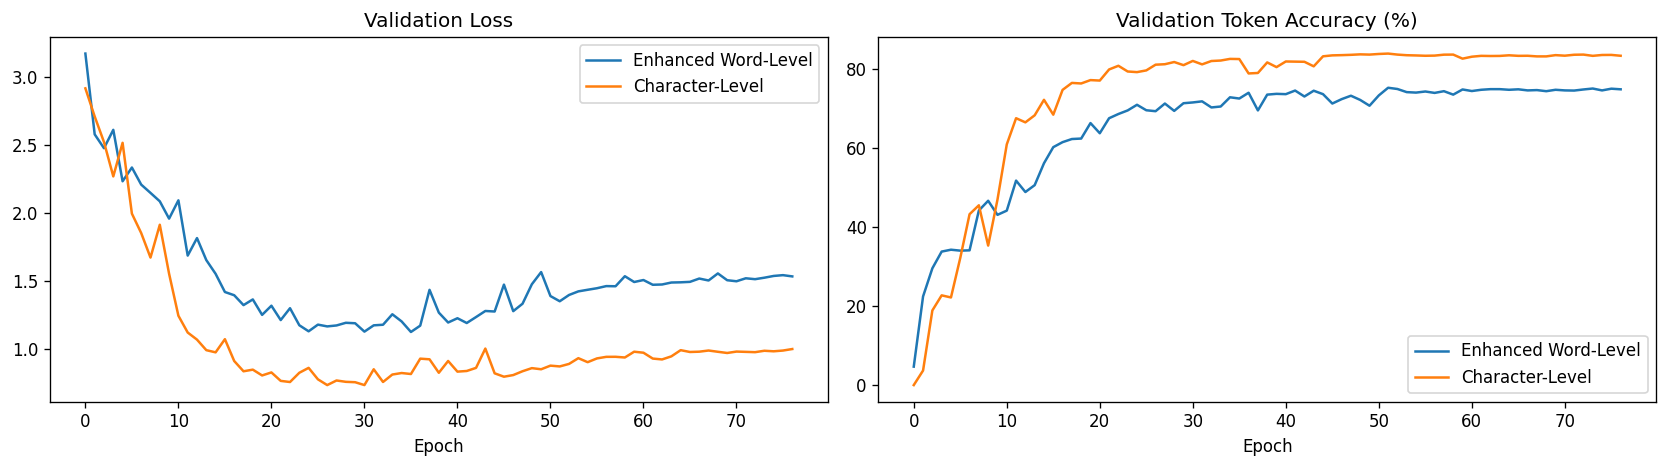

Best val acc — Word-level: 75.24%  |  Char-level: 83.88%


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, key, title in [
    (axes[0], 'val_loss', 'Validation Loss'),
    (axes[1], 'val_acc',  'Validation Token Accuracy (%)'),
]:
    ax.plot(wl_history[key], label='Enhanced Word-Level')
    ax.plot(cl_history[key], label='Character-Level')
    ax.set_xlabel('Epoch')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.savefig(ARTIFACTS / 'partC_improved_training_curves.png', bbox_inches='tight')
plt.show()

print(f'Best val acc — Word-level: {wl_best_val:.2f}%  |  Char-level: {cl_best_val:.2f}%')

## 7. Post-Processing: Dictionary Matching & Linear Search

Even a well-trained CRNN can produce out-of-vocabulary tokens or accidentally merge two adjacent
words into one.  We add a two-stage post-processing layer:

**Stage 1 – Minimum Edit Distance (MED) correction.**  
For every decoded token that is *not* in the training dictionary we find the closest valid word
and substitute it.  Ties are resolved in Stage 3 (Mutual Enhancement).

**Stage 2 – Linear Search for merged words.**  
If no close single-word match exists, we try *all* possible split-points of the unknown token,
looking for a pair `(left, right)` that are both in the dictionary.  The split with the lowest
combined edit distance is preferred.

In [13]:
# ── Build dictionary from training labels ────────────────────────────────────
# We use normalized word-level tokens as the canonical dictionary.
DICTIONARY = set()
for token_list in train_labels_wl.values():
    DICTIONARY.update(token_list)

# Remove the CTC blank placeholder if accidentally included
DICTIONARY.discard('<blank>')

DICT_LIST = sorted(DICTIONARY)  # sorted list for deterministic tie-breaking

print(f'Dictionary size: {len(DICTIONARY)} unique tokens')
print(f'Sample entries : {DICT_LIST[:10]}')

Dictionary size: 223 unique tokens
Sample entries : ['#١٥٠٠٠٠#', '64/100', 'آ', 'أ', 'أالف', 'أثن', 'أثنا', 'أحد', 'أحدا', 'أحدى']


In [14]:
def med_correct(token, dictionary, max_dist=2):
    """
    Return a list of (distance, candidate) pairs from `dictionary` that
    are within `max_dist` of `token`.  Returns [(0, token)] if the token
    is already in the dictionary.
    """
    if token in dictionary:
        return [(0, token)]

    token_chars = list(token)
    candidates = []
    for word in dictionary:
        d = edit_distance(token_chars, list(word))
        if d <= max_dist:
            candidates.append((d, word))

    candidates.sort(key=lambda x: x[0])
    return candidates  # empty list ↔ no close match found


def linear_split_search(token, dictionary):
    """
    Try every split of `token` into two non-empty sub-strings.
    Return the (left, right) pair where both halves have minimum combined
    edit distance to their nearest dictionary words.
    Returns None if no split yields two in-vocabulary words within distance 1 each.
    """
    best_pair  = None
    best_score = float('inf')

    for split in range(1, len(token)):
        left  = token[:split]
        right = token[split:]

        left_cands  = med_correct(left,  dictionary, max_dist=1)
        right_cands = med_correct(right, dictionary, max_dist=1)

        if left_cands and right_cands:
            score = left_cands[0][0] + right_cands[0][0]
            if score < best_score:
                best_score = score
                best_pair  = (left_cands[0][1], right_cands[0][1])

    return best_pair


def postprocess_sequence(tokens, dictionary, max_med_dist=2):
    """
    Apply MED + linear-split post-processing to a decoded token sequence.

    Returns
    -------
    corrected_tokens : list[str]
        Post-processed token sequence (may be longer if splits occurred).
    candidates_map   : dict  token_idx → list[(dist, candidate)]
        For each position that needed correction, the list of MED candidates
        (used by Mutual Enhancement to break ties).
    """
    corrected      = []
    candidates_map = {}  # position in output → MED candidates list

    for tok in tokens:
        if tok in dictionary:
            corrected.append(tok)
            continue

        cands = med_correct(tok, dictionary, max_dist=max_med_dist)

        if cands:
            # Record position and candidates before choosing the top one
            pos = len(corrected)
            candidates_map[pos] = cands
            corrected.append(cands[0][1])  # placeholder (tie-breaker may override)

        else:
            # Try splitting the unknown token into two valid words
            pair = linear_split_search(tok, dictionary)
            if pair:
                corrected.extend(list(pair))
            else:
                corrected.append(tok)  # keep as-is (unresolvable)

    return corrected, candidates_map


# ── Quick sanity check ───────────────────────────────────────────────────────
test_tok = 'خمسمائه'  # variant not in dictionary (if normalization is applied)
print(f'MED candidates for "{test_tok}":')
for d, w in med_correct(test_tok, DICTIONARY):
    print(f'  distance={d}  word={w}')

MED candidates for "خمسمائه":
  distance=1  word=خمسمائة
  distance=1  word=خمسائه
  distance=1  word=خمسمائ
  distance=2  word=خمسمئ
  distance=2  word=نمثمائه
  distance=2  word=خمسلمائ


In [15]:
def get_raw_predictions(model, test_loader, i2t, model_tag):
    """Run the model on the test set and collect raw decoded predictions."""
    model.load_state_dict(torch.load(
        MODEL_DIR / f'best_{model_tag}.pt',
        map_location=DEVICE
    ))
    model.eval()

    all_refs, all_hyps = [], []

    with torch.no_grad():
        for imgs, labels, in_lens, lbl_lens in tqdm(test_loader, desc='Test eval'):
            imgs      = imgs.to(DEVICE)
            log_probs = model(imgs)
            T_actual  = log_probs.size(0)
            in_lens   = torch.clamp(in_lens, max=T_actual)

            offset = 0
            for i, llen in enumerate(lbl_lens.tolist()):
                ref = [i2t[idx] for idx in labels[offset:offset + llen].tolist()]
                hyp = greedy_decode(log_probs[:, i, :], i2t)
                all_refs.append(ref)
                all_hyps.append(hyp)
                offset += llen

    return all_refs, all_hyps


# ── Get raw predictions from both models ────────────────────────────────────
print('── Word-level model ──')
wl_refs, wl_hyps_raw = get_raw_predictions(wl_model, wl_test_loader, wl_i2t, 'wl')

print('── Character-level model ──')
cl_refs, cl_hyps_raw = get_raw_predictions(cl_model, cl_test_loader, cl_i2t, 'cl')

── Word-level model ──


Test eval: 100%|██████████| 38/38 [00:04<00:00,  8.30it/s]


── Character-level model ──


Test eval: 100%|██████████| 38/38 [00:01<00:00, 29.23it/s]


In [16]:
def apply_postprocessing(hyps_raw, dictionary):
    """
    Apply dictionary-based post-processing to a list of decoded sequences.

    For the character-level model the 'tokens' are individual characters;
    we first join them into a string and split on whitespace to recover
    word-level tokens before applying MED.
    """
    is_char_level = all(len(t) == 1 for hyp in hyps_raw[:5] for t in hyp if t)

    corrected_hyps = []
    all_cand_maps  = []

    for hyp in hyps_raw:
        if is_char_level:
            # join characters back into the full Arabic string, then
            # reconstruct word tokens by lexical matching against the dictionary
            joined = ''.join(hyp)
            # naive split: try dictionary words greedily from left to right
            words = greedy_word_segment(joined, dictionary)
        else:
            words = hyp

        corrected, cmap = postprocess_sequence(words, dictionary)
        corrected_hyps.append(corrected)
        all_cand_maps.append(cmap)

    return corrected_hyps, all_cand_maps


def greedy_word_segment(text, dictionary):
    """
    Greedy longest-match word segmentation.
    Scans `text` left-to-right, greedily consuming the longest prefix that
    matches a dictionary word.
    """
    words   = []
    i       = 0
    max_len = max((len(w) for w in dictionary), default=1)

    while i < len(text):
        best_match = None
        for length in range(min(max_len, len(text) - i), 0, -1):
            candidate = text[i:i + length]
            if candidate in dictionary:
                best_match = candidate
                break
        if best_match:
            words.append(best_match)
            i += len(best_match)
        else:
            # Single character — keep as unknown fragment
            words.append(text[i])
            i += 1

    return words


print('Applying post-processing to word-level predictions...')
wl_hyps_pp, wl_cand_maps = apply_postprocessing(wl_hyps_raw, DICTIONARY)

print('Applying post-processing to character-level predictions...')
cl_hyps_pp, cl_cand_maps = apply_postprocessing(cl_hyps_raw, DICTIONARY)

Applying post-processing to word-level predictions...
Applying post-processing to character-level predictions...


## 8. Evaluation & Comparison

We compare **four configurations**. Mutual Enhancement (courtesy tie-breaking) is handled in `04_Part_D_Verification.ipynb`.

| # | Configuration |
|---|---------------|
| 1 | Word-level — raw CTC output |
| 2 | Word-level — + post-processing (MED + linear search) |
| 3 | Char-level  — raw CTC output |
| 4 | Char-level  — + post-processing (MED + linear search) |


In [17]:
def evaluate(refs, hyps, label):
    m = legal_summary(refs, hyps)
    print(f'{label:<52}  CER={m["CER"]:5.2f}%  WER={m["WER"]:5.2f}%')
    return m


results = {}
header = f'{"Configuration":<52}  {"CER":>8}  {"WER":>8}'
print(header)
print('-' * 74)

results['wl_raw'] = evaluate(wl_refs, wl_hyps_raw, '1. Word-level  raw')
results['wl_pp']  = evaluate(wl_refs, wl_hyps_pp,  '2. Word-level  + post-processing')
results['cl_raw'] = evaluate(cl_refs, cl_hyps_raw, '3. Char-level  raw')
results['cl_pp']  = evaluate(cl_refs, cl_hyps_pp,  '4. Char-level  + post-processing')


Configuration                                              CER       WER
--------------------------------------------------------------------------
1. Word-level  raw                                    CER=39.63%  WER=84.67%
2. Word-level  + post-processing                      CER=39.63%  WER=84.67%
3. Char-level  raw                                    CER= 9.41%  WER=78.00%
4. Char-level  + post-processing                      CER=80.38%  WER=82.67%


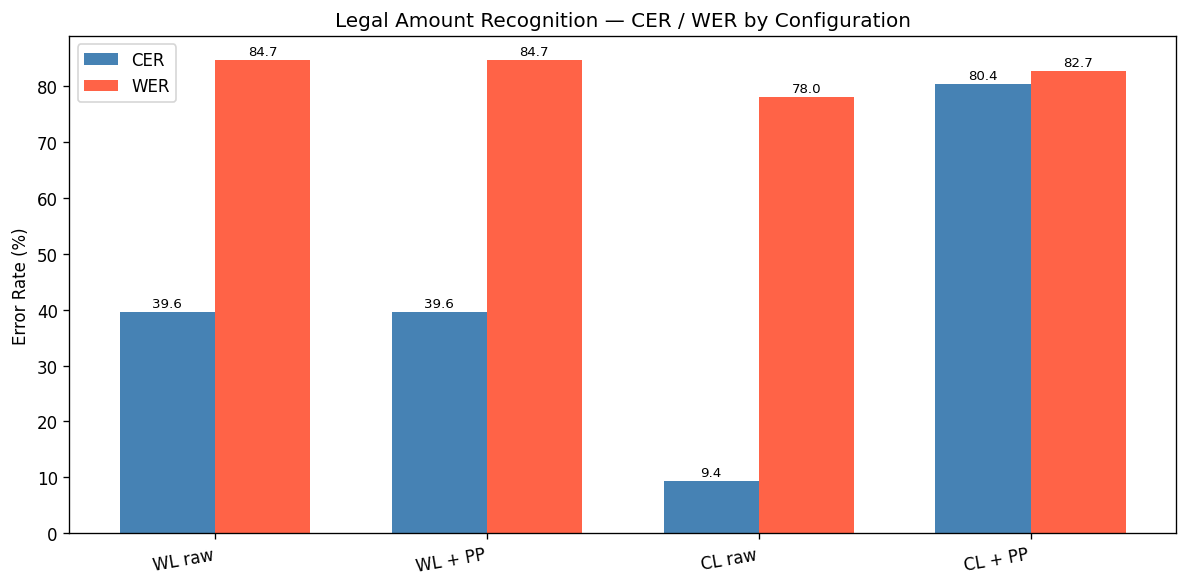

In [18]:
labels   = ['WL raw', 'WL + PP', 'CL raw', 'CL + PP']
cer_vals = [results[k]['CER'] for k in ('wl_raw', 'wl_pp', 'cl_raw', 'cl_pp')]
wer_vals = [results[k]['WER'] for k in ('wl_raw', 'wl_pp', 'cl_raw', 'cl_pp')]

x     = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_cer = ax.bar(x - width/2, cer_vals, width, label='CER', color='steelblue')
bars_wer = ax.bar(x + width/2, wer_vals, width, label='WER', color='tomato')

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=10, ha='right')
ax.set_ylabel('Error Rate (%)')
ax.set_title('Legal Amount Recognition — CER / WER by Configuration')
ax.legend()

for bar in (*bars_cer, *bars_wer):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(ARTIFACTS / 'partC_improved_comparison.png', bbox_inches='tight')
plt.show()


## 10. Error Analysis

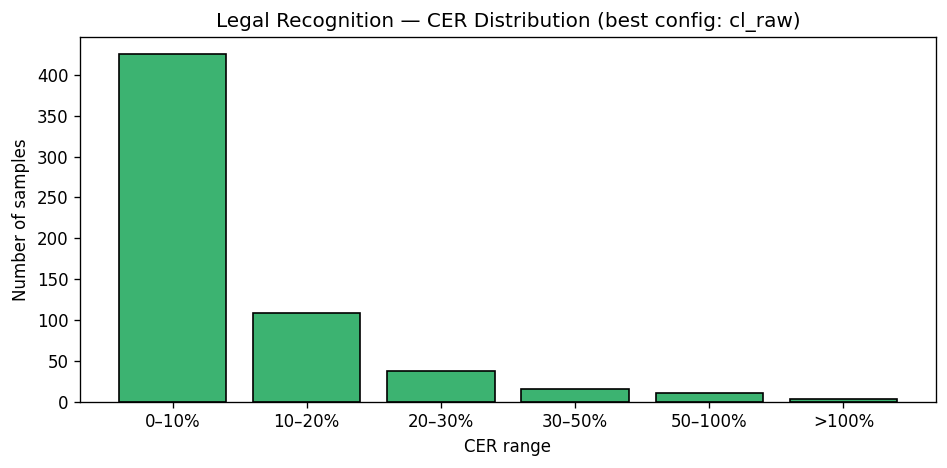

Perfect predictions (CER=0): 425 / 600

── Best predictions ──
  CER=0.00 | ref: عشرةآلافريالفقطلاغير | pred: عشرةآلافريالفقطلاغير
  CER=0.00 | ref: خمسةآلافرياللاغير | pred: خمسةآلافرياللاغير
  CER=0.00 | ref: فقطألفرياللاغير | pred: فقطألفرياللاغير
  CER=0.00 | ref: فقطأربعمائةوخمسونرياللاغير | pred: فقطأربعمائةوخمسونرياللاغير
  CER=0.00 | ref: فقطألفانوثمانمائةرياللاغير | pred: فقطألفانوثمانمائةرياللاغير

── Worst predictions ──
  CER=0.86 | ref: الفريال | pred: ستةآلافريالل
  CER=0.87 | ref: ثلاثهالفريالفقط | pred: ثلاثهألفرياربعورياللاغير
  CER=1.00 | ref: الفريالفقط | pred: ألفريالووسعنريال
  CER=1.00 | ref: اربعونالفرياللاغير | pred: أربعةآلافوخمسارةهنريالوملة
  CER=1.07 | ref: اثناعشرالفريال | pred: نانعشألفوريالوخقطلاغير


In [19]:
# ── Per-sample CER distribution for the best configuration ──────────────────
best_key = min(results, key=lambda k: results[k]['CER'])
best_label_map = {
    'wl_raw': (wl_refs, wl_hyps_raw),
    'wl_pp' : (wl_refs, wl_hyps_pp),
    'cl_raw': (cl_refs, cl_hyps_raw),
    'cl_pp' : (cl_refs, cl_hyps_pp),
}
best_refs, best_hyps = best_label_map[best_key]

per_sample = [
    {'cer': edit_distance(r, h) / max(len(r), 1), 'ref': r, 'hyp': h}
    for r, h in zip(best_refs, best_hyps)
]

cer_vals_ps = [s['cer'] for s in per_sample]
bins       = [0, 0.1, 0.2, 0.3, 0.5, 1.0, float('inf')]
bin_labels = ['0–10%', '10–20%', '20–30%', '30–50%', '50–100%', '>100%']
counts     = [sum(b1 <= c < b2 for c in cer_vals_ps) for b1, b2 in zip(bins[:-1], bins[1:])]

plt.figure(figsize=(8, 4))
plt.bar(bin_labels, counts, color='mediumseagreen', edgecolor='black')
plt.xlabel('CER range')
plt.ylabel('Number of samples')
plt.title(f'Legal Recognition — CER Distribution (best config: {best_key})')
plt.tight_layout()
plt.savefig(ARTIFACTS / 'partC_improved_cer_dist.png', bbox_inches='tight')
plt.show()

print(f'Perfect predictions (CER=0): {counts[0]} / {len(cer_vals_ps)}')

sorted_samples = sorted(per_sample, key=lambda x: x['cer'])
print('\n── Best predictions ──')
for s in sorted_samples[:5]:
    print(f"  CER={s['cer']:.2f} | ref: {''.join(s['ref'])} | pred: {''.join(s['hyp'])}")
print('\n── Worst predictions ──')
for s in sorted_samples[-5:]:
    print(f"  CER={s['cer']:.2f} | ref: {''.join(s['ref'])} | pred: {''.join(s['hyp'])}")


In [20]:
from collections import Counter


def substitution_pairs(ref, hyp):
    n, m = len(ref), len(hyp)
    dp = [[(0, '')] * (m + 1) for _ in range(n + 1)]
    for i in range(n + 1): dp[i][0] = (i, 'D')
    for j in range(m + 1): dp[0][j] = (j, 'I')
    dp[0][0] = (0, '')
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            if ref[i-1] == hyp[j-1]:
                dp[i][j] = (dp[i-1][j-1][0], 'M')
            else:
                best = min(
                    (dp[i-1][j][0] + 1, 'D'),
                    (dp[i][j-1][0] + 1, 'I'),
                    (dp[i-1][j-1][0] + 1, 'S'),
                )
                dp[i][j] = best
    pairs = []
    i, j = n, m
    while i > 0 or j > 0:
        _, op = dp[i][j]
        if op == 'S':   pairs.append((ref[i-1], hyp[j-1])); i -= 1; j -= 1
        elif op == 'D': i -= 1
        elif op == 'I': j -= 1
        else:           i -= 1; j -= 1
    return pairs


sub_counter = Counter()
for r, h in zip(best_refs, best_hyps):
    sub_counter.update(substitution_pairs(r, h))

print(f'Top 10 substitutions (ref → pred) for best config [{best_key}]:')
for (rt, ht), cnt in sub_counter.most_common(10):
    print(f'  "{rt}"  →  "{ht}"   ({cnt}×)')

Top 10 substitutions (ref → pred) for best config [cl_raw]:
  "ا"  →  "أ"   (190×)
  "ه"  →  "ة"   (155×)
  "ا"  →  "آ"   (77×)
  "ة"  →  "ه"   (44×)
  "أ"  →  "ا"   (18×)
  "أ"  →  "آ"   (13×)
  "إ"  →  "ا"   (7×)
  "د"  →  "ر"   (5×)
  "ئ"  →  "ن"   (4×)
  "ا"  →  "ف"   (4×)


## 11. Save Results

In [21]:

# Save the best-configuration predictions (used as input to Part D)
best_test_ds = wl_test_ds if best_key.startswith('wl') else cl_test_ds
is_char_level = best_key.startswith('cl')


def _chars_to_words(chars):
    """Join individual characters and re-segment into word tokens."""
    return greedy_word_segment(''.join(chars), DICTIONARY)


predictions_out = []
for (img_path, _), ref, hyp in zip(best_test_ds.samples, best_refs, best_hyps):
    fname = img_path.name
    stem  = fname[1:].replace('.tif', '')

    if is_char_level:
        # Reference: use normalized word-level labels (ground truth) so
        # Part D can parse them with legal_text_to_digits
        ref_words = test_labels_wl.get(fname) or _chars_to_words(ref)
        hyp_words = _chars_to_words(hyp)
        ref_str = ' '.join(ref_words)
        hyp_str = ' '.join(hyp_words)
    else:
        ref_str = ' '.join(ref)
        hyp_str = ' '.join(hyp)

    predictions_out.append({
        'file'      : fname,
        'stem'      : stem,
        'reference' : ref_str,
        'predicted' : hyp_str,
        'config'    : best_key,
    })

with open(ARTIFACTS / 'partC_improved_predictions.json', 'w', encoding='utf-8') as f:
    json.dump(predictions_out, f, indent=2, ensure_ascii=False)

with open(ARTIFACTS / 'partC_improved_metrics.json', 'w') as f:
    json.dump(results, f, indent=2)

print(f'Saved {len(predictions_out)} predictions  (config: {best_key})')
print('Files written:')
print('  artifacts/partC_improved_predictions.json')
print('  artifacts/partC_improved_metrics.json')
print('  artifacts/partC_improved_training_curves.png')
print('  artifacts/partC_improved_comparison.png')
print('  artifacts/partC_improved_cer_dist.png')


Saved 600 predictions  (config: cl_raw)
Files written:
  artifacts/partC_improved_predictions.json
  artifacts/partC_improved_metrics.json
  artifacts/partC_improved_training_curves.png
  artifacts/partC_improved_comparison.png
  artifacts/partC_improved_cer_dist.png


## 12. Summary

In [23]:
print('═' * 60)
print(' Part C Improved — Results Summary')
print('═' * 60)
print()
print('A. Vocabulary sizes')
print(f'   Baseline sub-word  : {len(raw_vocab)} tokens')
print(f'   Enhanced word-level: {len(wl_vocab)} tokens  (normalized spelling)')
print(f'   Character-level    : {len(cl_vocab)} tokens  (~24 Arabic chars)')
print()
print('B. Model training (best validation accuracy)')
print(f'   Enhanced word-level model: {wl_best_val:.2f}%')
print(f'   Character-level model    : {cl_best_val:.2f}%')
print()
print('C. Test-set evaluation')
col_w = 52
print(f"   {'Configuration':<{col_w}} {'CER':>6}  {'WER':>6}")
print('   ' + '-' * (col_w + 16))
config_labels = {
    'wl_raw': 'Word-level  (raw CTC)',
    'wl_pp' : 'Word-level  + dictionary post-processing',
    'cl_raw': 'Char-level  (raw CTC)',
    'cl_pp' : 'Char-level  + dictionary post-processing',
}
for key, lbl in config_labels.items():
    m   = results[key]
    mrk = '  ← best' if key == best_key else ''
    print(f"   {lbl:<{col_w}} {m['CER']:>5.2f}%  {m['WER']:>5.2f}%{mrk}")
print()
print('D. Post-processing gain  (best config vs raw baseline)')
raw_key = 'cl_raw' if best_key.startswith('cl') else 'wl_raw'
delta_cer = results[raw_key]['CER'] - results[best_key]['CER']
delta_wer = results[raw_key]['WER'] - results[best_key]['WER']
print(f'   CER reduced by {delta_cer:+.2f}%')
print(f'   WER reduced by {delta_wer:+.2f}%')
print()
print('→ Mutual Enhancement & final verification → 04_Part_D_Verification.ipynb')
print('═' * 60)


════════════════════════════════════════════════════════════
 Part C Improved — Results Summary
════════════════════════════════════════════════════════════

A. Vocabulary sizes
   Baseline sub-word  : 288 tokens
   Enhanced word-level: 270 tokens  (normalized spelling)
   Character-level    : 53 tokens  (~24 Arabic chars)

B. Model training (best validation accuracy)
   Enhanced word-level model: 75.24%
   Character-level model    : 83.88%

C. Test-set evaluation
   Configuration                                           CER     WER
   --------------------------------------------------------------------
   Word-level  (raw CTC)                                39.63%  84.67%
   Word-level  + dictionary post-processing             39.63%  84.67%
   Char-level  (raw CTC)                                 9.41%  78.00%  ← best
   Char-level  + dictionary post-processing             80.38%  82.67%

D. Post-processing gain  (best config vs raw baseline)
   CER reduced by +0.00%
   WER reduced 